# Evaluate Model v2 — Stage 1 & Stage 2

Evaluate RT-DETR v2 models trained with two-stage strategy:
- **Stage 1**: Pre-trained on synthetic data (`kaya-go/moku-v2`, revision `stage1`)
- **Stage 2**: Fine-tuned on real data with LR sweep (`stage2-lr1e-5`, `stage2-lr2e-5`, `stage2-lr5e-5`)

**Sections:**
1. Load datasets and models (stage 1 + 3 stage 2 LR runs)
2. Compute mAP metrics (per stage/LR)
3. Side-by-side comparison table
4. Visualize predictions (best stage 2 vs stage 1 vs GT)

In [17]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.training import (
    collate_fn,
    evaluate_center_distance,
    evaluate_map,
    format_center_distance_results,
    format_map_per_class,
    format_map_results,
    make_eval_transform,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [2]:
HF_MODEL = "kaya-go/moku-v2"
HF_DATASET = "kaya-go/moku-v2"
THRESHOLD = 0.05

# Stage 2 LR sweep branches
STAGE2_RUNS = {
    "lr=1e-5": "stage2-lr1e-5",
    "lr=2e-5": "stage2-lr2e-5",
    "lr=5e-5": "stage2-lr5e-5",
}

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


## Load Datasets

In [3]:
# Synthetic dataset (stage 1 eval)
ds_synthetic = load_dataset(HF_DATASET, "synthetic")
print("Synthetic dataset:")
print(ds_synthetic)

# Real dataset (stage 2 eval)
ds_real = load_dataset(HF_DATASET, "real")
print("\nReal dataset:")
print(ds_real)

Synthetic dataset:
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 2500
    })
    validation: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 500
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 500
    })
})

Real dataset:
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 382
    })
    validation: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 53
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 50
    })
})


## Load Models

Stage 1 from branch `stage1`, Stage 2 from per-LR branches.

In [4]:
def _load_model(revision: str):
    ip = RTDetrImageProcessor.from_pretrained(HF_MODEL, revision=revision)
    model = RTDetrForObjectDetection.from_pretrained(
        HF_MODEL,
        revision=revision,
        num_labels=len(CATEGORIES),
        id2label=ID_TO_CATEGORY,
        label2id=CATEGORIES,
    )
    print(f"  Loaded {HF_MODEL} (revision={revision})")
    return ip, model

# Stage 1
print("Stage 1:")
ip_stage1, model_stage1 = _load_model("stage1")

# Stage 2 LR sweep
stage2_models = {}
for label, revision in STAGE2_RUNS.items():
    print(f"Stage 2 ({label}):")
    try:
        ip, model = _load_model(revision)
        stage2_models[label] = {"ip": ip, "model": model, "revision": revision}
    except Exception as e:
        print(f"  ⚠ Not found (not trained yet?): {e}")

print(f"\nLoaded: 1 stage 1 + {len(stage2_models)} stage 2 models")

Stage 1:


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

  Loaded kaya-go/moku-v2 (revision=stage1)
Stage 2 (lr=1e-5):
  ⚠ Not found (not trained yet?): stage2-lr1e-5 is not a valid git identifier (branch name, tag name or commit id) that exists for this model name. Check the model page at 'https://huggingface.co/kaya-go/moku-v2' for available revisions.
Stage 2 (lr=2e-5):
  ⚠ Not found (not trained yet?): stage2-lr2e-5 is not a valid git identifier (branch name, tag name or commit id) that exists for this model name. Check the model page at 'https://huggingface.co/kaya-go/moku-v2' for available revisions.
Stage 2 (lr=5e-5):
  ⚠ Not found (not trained yet?): stage2-lr5e-5 is not a valid git identifier (branch name, tag name or commit id) that exists for this model name. Check the model page at 'https://huggingface.co/kaya-go/moku-v2' for available revisions.

Loaded: 1 stage 1 + 0 stage 2 models


## Stage 1 — mAP on Synthetic Validation

In [7]:
ds_synthetic.set_transform(make_eval_transform(ip_stage1))

metrics_s1_synth = evaluate_map(
    model=model_stage1,
    dataset=ds_synthetic["validation"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

print("=== Stage 1 — Synthetic Validation ===")
display(format_map_results(metrics_s1_synth))
print("\nPer-Class AP:")
display(format_map_per_class(metrics_s1_synth))

=== Stage 1 — Synthetic Validation ===


,metric,value
0,mAP@50:95,0.5838
1,mAP@50,0.6631
2,mAP@75,0.6001
3,mAR@400,0.7454



Per-Class AP:


,category,AP@50:95
0,black_stone,0.8670
1,white_stone,0.7723
2,board_corner,0.1120


## Stage 1 — mAP on Real Test

How well does the synthetic-only model generalize to real images?

In [12]:
THRESHOLD = 0.05

ds_real.set_transform(make_eval_transform(ip_stage1))

metrics_s1_real = evaluate_map(
    model=model_stage1,
    dataset=ds_real["test"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

print("=== Stage 1 — Real Test ===")
display(format_map_results(metrics_s1_real))
print("\nPer-Class AP:")
display(format_map_per_class(metrics_s1_real))

=== Stage 1 — Real Test ===


,metric,value
0,mAP@50:95,0.0112
1,mAP@50,0.0339
2,mAP@75,0.0056
3,mAR@400,0.0833



Per-Class AP:


,category,AP@50:95
0,black_stone,0.0166
1,white_stone,0.0168
2,board_corner,0.0000


## Stage 2 — mAP on Real Test (all LR runs)

In [13]:
metrics_s2 = {}

if not stage2_models:
    print("No stage 2 models available yet — skipping.")
else:
    for label, entry in stage2_models.items():
        ds_real.set_transform(make_eval_transform(entry["ip"]))
        m = evaluate_map(
            model=entry["model"],
            dataset=ds_real["test"],
            image_processor=entry["ip"],
            batch_size=8,
            threshold=THRESHOLD,
        )
        metrics_s2[label] = m
        print(f"=== Stage 2 ({label}) — Real Test ===")
        display(format_map_results(m))
        print("Per-Class AP:")
        display(format_map_per_class(m))
        print()

No stage 2 models available yet — skipping.


## Center-Distance Evaluation

mAP penalizes bbox size mismatches, but for our use case only the **center point** matters:
- **board_corner**: center → homography point
- **stones**: center → snap to nearest grid intersection

The center-distance metric reports Precision/Recall/F1 at various distance thresholds
(as % of image diagonal). A detection is "correct" if its center is within X% of the
diagonal from the nearest GT center of the same class.

In [18]:
# Stage 1 → Synthetic Validation (center-distance)
ds_synthetic.set_transform(make_eval_transform(ip_stage1))
cd_s1_synth = evaluate_center_distance(
    model=model_stage1,
    dataset=ds_synthetic["validation"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)
print("=== Stage 1 — Synthetic Validation (Center Distance) ===")
display(format_center_distance_results(cd_s1_synth))

# Stage 1 → Real Test (center-distance)
ds_real.set_transform(make_eval_transform(ip_stage1))
cd_s1_real = evaluate_center_distance(
    model=model_stage1,
    dataset=ds_real["test"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)
print("\n=== Stage 1 — Real Test (Center Distance) ===")
display(format_center_distance_results(cd_s1_real))

# Stage 2 runs (center-distance)
cd_s2 = {}
for label, entry in stage2_models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    cd = evaluate_center_distance(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
        threshold=THRESHOLD,
    )
    cd_s2[label] = cd
    print(f"\n=== Stage 2 ({label}) — Real Test (Center Distance) ===")
    display(format_center_distance_results(cd))

=== Stage 1 — Synthetic Validation (Center Distance) ===


,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,4550,4761,4377,2.51,0.30,0.9021,0.9440,0.9226,0.9021,0.9440,0.9226,0.9044,0.9464,0.9249
1,white_stone,4706,4004,3940,3.11,0.25,0.9643,0.8204,0.8866,0.9643,0.8204,0.8866,0.9675,0.8232,0.8896
2,board_corner,252,2025,234,16.27,0.95,0.1086,0.8730,0.1932,0.1086,0.8730,0.1932,0.1096,0.8810,0.1950



=== Stage 1 — Real Test (Center Distance) ===


,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,253,297,240,27.84,6.42,0.4242,0.4980,0.4582,0.4983,0.5850,0.5382,0.6397,0.7510,0.6909
1,white_stone,223,750,223,5.33,0.98,0.2560,0.8610,0.3947,0.2733,0.9193,0.4214,0.2907,0.9776,0.4481
2,board_corner,28,323,27,89.56,55.61,0.0124,0.1429,0.0228,0.0279,0.3214,0.0513,0.0372,0.4286,0.0684


## Comparison Table

Side-by-side comparison of all evaluation runs.

,mAP@50:95,mAP@50,mAP@75,mAR@400,AP_black_stone,AP_white_stone,AP_board_corner
model,,,,,,,
Stage 1 → Synth Val,0.5838,0.6631,0.6001,0.7454,0.8670,0.7723,0.112
Stage 1 → Real Test,0.0112,0.0339,0.0056,0.0833,0.0166,0.0168,0.000



No stage 2 results yet — only stage 1 metrics shown.


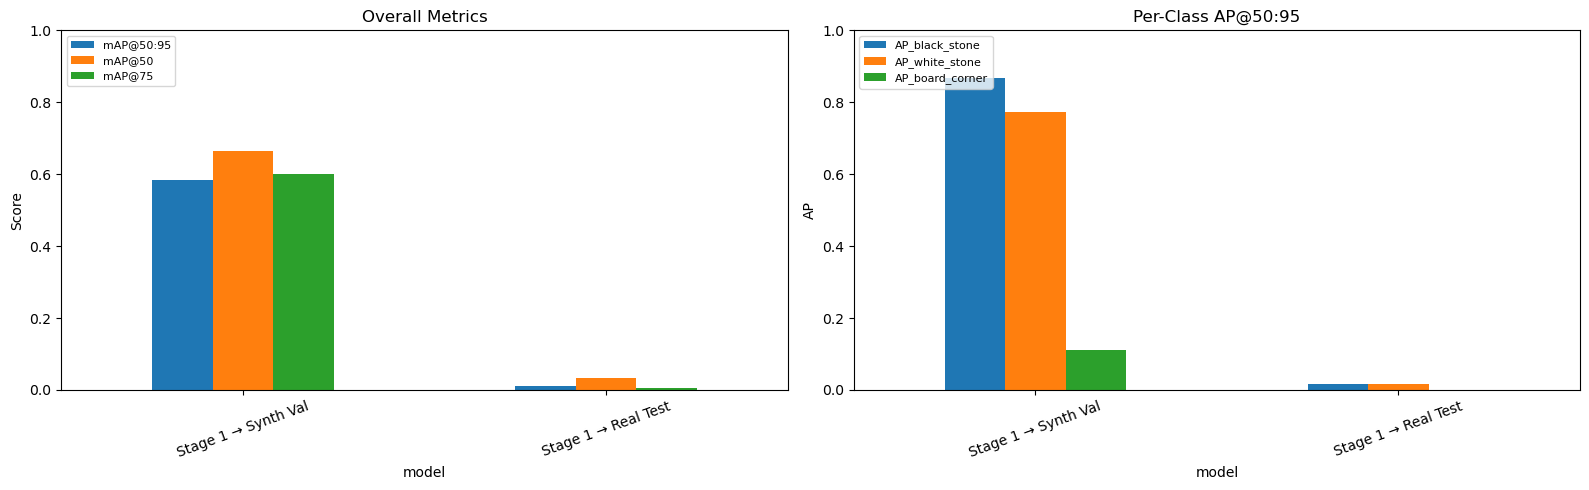

In [14]:
def _extract_summary(metrics: dict, label: str) -> dict:
    """Extract key metrics into a flat dict for comparison."""
    row = {
        "model": label,
        "mAP@50:95": round(float(metrics.get("map", 0)), 4),
        "mAP@50": round(float(metrics.get("map_50", 0)), 4),
        "mAP@75": round(float(metrics.get("map_75", 0)), 4),
        "mAR@400": round(float(metrics.get("mar_400", 0)), 4),
    }
    per_class = metrics.get("map_per_class")
    if per_class is not None and hasattr(per_class, "__iter__"):
        for i, ap in enumerate(per_class):
            name = ID_TO_CATEGORY.get(i, f"class_{i}")
            val = ap.item() if hasattr(ap, "item") else float(ap)
            row[f"AP_{name}"] = round(val, 4)
    return row

rows = [
    _extract_summary(metrics_s1_synth, "Stage 1 → Synth Val"),
    _extract_summary(metrics_s1_real, "Stage 1 → Real Test"),
]
for label, m in metrics_s2.items():
    rows.append(_extract_summary(m, f"Stage 2 ({label}) → Real Test"))

comparison = pd.DataFrame(rows).set_index("model")
display(comparison)

# Highlight best stage 2 run (if any)
s2_rows = comparison.filter(like="Stage 2", axis=0)
if not s2_rows.empty:
    best_label = s2_rows["mAP@50:95"].idxmax()
    print(f"\n✅ Best stage 2 run: {best_label} (mAP@50:95 = {comparison.loc[best_label, 'mAP@50:95']:.4f})")
else:
    print("\nNo stage 2 results yet — only stage 1 metrics shown.")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

comparison[["mAP@50:95", "mAP@50", "mAP@75"]].plot.bar(ax=axes[0], rot=20)
axes[0].set_title("Overall Metrics")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper left", fontsize=8)

ap_cols = [c for c in comparison.columns if c.startswith("AP_")]
if ap_cols:
    comparison[ap_cols].plot.bar(ax=axes[1], rot=20)
    axes[1].set_title("Per-Class AP@50:95")
    axes[1].set_ylabel("AP")
    axes[1].set_ylim(0, 1)
    axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## Visualize Predictions — Stage 1 vs Best Stage 2

Browse real test images and compare predictions from stage 1, the best stage 2 model, and ground truth.

In [15]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

# Pick the best stage 2 model for visualization
best_s2_key = comparison.filter(like="Stage 2", axis=0)["mAP@50:95"].idxmax()
# Extract the LR label from the comparison index (e.g. "Stage 2 (lr=2e-5) → Real Test" → "lr=2e-5")
best_lr = [k for k in stage2_models if k in best_s2_key][0]
best_s2 = stage2_models[best_lr]
print(f"Using best stage 2 model: {best_lr} (revision={best_s2['revision']})")

# Load raw real test images (no transforms) for visualization
raw_test = load_dataset(HF_DATASET, "real", split="test")

COLORS = {"black_stone": "#e7298a", "white_stone": "#1b9e77", "board_corner": "#d95f02"}


def _filter_predictions(preds, threshold):
    """Filter predictions by threshold; for board_corner, keep only top 4."""
    boxes, scores, labels = [], [], []
    corner_candidates = []
    for box, score, label_id in zip(preds["boxes"], preds["scores"], preds["labels"]):
        if score < threshold:
            continue
        if ID_TO_CATEGORY[label_id] == "board_corner":
            corner_candidates.append((box, score, label_id))
        else:
            boxes.append(box)
            scores.append(score)
            labels.append(label_id)
    corner_candidates.sort(key=lambda x: x[1], reverse=True)
    for box, score, label_id in corner_candidates[:4]:
        boxes.append(box)
        scores.append(score)
        labels.append(label_id)
    return boxes, scores, labels


def _draw_boxes(ax, image, boxes, scores, labels):
    ax.imshow(image)
    for box, score, label_id in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        name = ID_TO_CATEGORY[label_id]
        color = COLORS[name]
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, f"{name} {score:.2f}", fontsize=7, color=color, weight="bold")
    ax.axis("off")


def _draw_gt(ax, image, sample):
    ax.imshow(image)
    for bbox, cat_id in zip(sample["objects"]["bbox"], sample["objects"]["category"]):
        x, y, w, h = bbox
        name = ID_TO_CATEGORY[cat_id]
        color = COLORS[name]
        rect = plt.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 2, name, fontsize=7, color=color, weight="bold")
    ax.axis("off")


def _run_inference(model, image_processor, image):
    model_dev = model.to(device)
    model_dev.eval()
    inputs = image_processor(images=[image], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_dev(**inputs)
    target_size = torch.tensor([[image.height, image.width]])
    results = image_processor.post_process_object_detection(outputs, target_sizes=target_size, threshold=0.0)[0]
    return {
        "boxes": results["boxes"].cpu().tolist(),
        "scores": results["scores"].cpu().tolist(),
        "labels": results["labels"].cpu().tolist(),
    }


# Pre-compute predictions for stage 1 and best stage 2
print("Running inference (stage 1)...")
preds_stage1 = [_run_inference(model_stage1, ip_stage1, raw_test[i]["image"].convert("RGB")) for i in range(len(raw_test))]
print(f"Running inference (best stage 2: {best_lr})...")
preds_stage2 = [_run_inference(best_s2["model"], best_s2["ip"], raw_test[i]["image"].convert("RGB")) for i in range(len(raw_test))]
print(f"Done. {len(raw_test)} images processed for each model.")

# Interactive widget
output = widgets.Output()

slider = widgets.IntSlider(value=0, min=0, max=len(raw_test) - 1, step=1, description="Image:")
threshold_slider = widgets.FloatSlider(value=THRESHOLD, min=0.0, max=1.0, step=0.01, description="Threshold:", readout_format=".2f")
show_gt = widgets.Checkbox(value=True, description="Show GT")


def update_viz(change=None):
    output.clear_output(wait=True)
    with output:
        idx = slider.value
        threshold = threshold_slider.value
        sample = raw_test[idx]
        image = sample["image"].convert("RGB")

        ncols = 3 if show_gt.value else 2
        fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 7))

        # Stage 1 predictions
        boxes1, scores1, labels1 = _filter_predictions(preds_stage1[idx], threshold)
        _draw_boxes(axes[0], image, boxes1, scores1, labels1)
        axes[0].set_title(f"Stage 1 ({len(boxes1)} detections)", fontsize=11)

        # Best stage 2 predictions
        boxes2, scores2, labels2 = _filter_predictions(preds_stage2[idx], threshold)
        _draw_boxes(axes[1], image, boxes2, scores2, labels2)
        axes[1].set_title(f"Stage 2 {best_lr} ({len(boxes2)} detections)", fontsize=11)

        # Ground truth
        if show_gt.value:
            n_gt = len(sample["objects"]["bbox"])
            _draw_gt(axes[2], image, sample)
            axes[2].set_title(f"Ground Truth ({n_gt} annotations)", fontsize=11)

        fig.suptitle(f"Real test image {idx}", fontsize=13, weight="bold")
        plt.tight_layout()
        plt.show()


slider.observe(update_viz, names="value")
threshold_slider.observe(update_viz, names="value")
show_gt.observe(update_viz, names="value")

ipy_display(widgets.VBox([widgets.HBox([slider, threshold_slider, show_gt]), output]))
update_viz()

ValueError: attempt to get argmax of an empty sequence